In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    'Date': ['2025-10-10', '2025-10-11', '2025-10-12', '2025-10-13', '2025-10-14', 
             '2025-10-15', '2025-10-16', '2025-10-17', '2025-10-18', '2025-10-19',
             '2025-10-20', '2025-10-21', '2025-10-22', '2025-10-23', '2025-10-24',
             '2025-10-25', '2025-10-26', '2025-10-27', '2025-10-28', '2025-10-29',
             '2025-10-30', '2025-10-31', '2025-11-01', '2025-11-02', '2025-11-03',
             '2025-11-04', '2025-11-05', '2025-11-06', '2025-11-07', '2025-11-08', '2025-11-09'],
    'Loaded': [17344, 17311, 21978, 19850, 14896, 19747, 19299, 18966, 18010, 18782,
               22674, 21819, 17832, 13617, 21122, 17320, 20628, 13391, 16669, 18921,
               16605, 15138, 17235, 19006, 18675, 11456, 11109, 12216, 14870, 16425, 13573],
    'Aggregated': [0, 16235, 16198, 20855, 18705, 13809, 18323, 18513, 17898, 16873,
                17742, 21349, 20976, 16573, 12643, 19845, 34030, 20607, 13161, 16718,
                19123, 16605, 15040, 17332, 18821, 18861, 11455, 11102, 12203, 14890, 16424],
    'IBR Flows': [0, 7241, 10161, 11499, 11178, 6685, 8809, 8708, 8623, 8525,
               9725, 10986, 11005, 8287, 5212, 9523, 9068, 9061, 7513, 9502,
               8965, 7198, 7301, 9969, 10954, 8458, 6105, 4885, 6625, 6769, 6763],
    'Remaining': [17344, 18420, 24200, 23195, 19386, 25324, 26300, 26753, 26865, 28774,
                  33706, 34176, 31032, 28076, 36555, 34030, 20628, 13412, 16920, 19123,
                  16605, 15138, 17333, 19007, 18861, 11456, 11110, 12224, 14891, 16426, 13575]
}

# Delta como enteros para plotting (quitando el signo para valores absolutos)
delta_str = ['+17344', '+1076', '+5780', '-1005', '-3809', '+5938', '+976', '+453', '+112', '+1909',
             '+4932', '+470', '-3144', '-2956', '+8479', '-2525', '-13402', '-7216', '+3508', '+2203',
             '-2518', '-1467', '+2195', '+1674', '-146', '-7405', '-346', '+1114', '+2667', '+1535', '-2851']

In [3]:
# Convert delta strings to integers
data['Delta'] = [int(d.replace('+', '').replace('-', '')) * (1 if d.startswith('+') else -1) for d in delta_str]

# Create DataFrame
df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date'])

<Figure size 1600x1000 with 0 Axes>

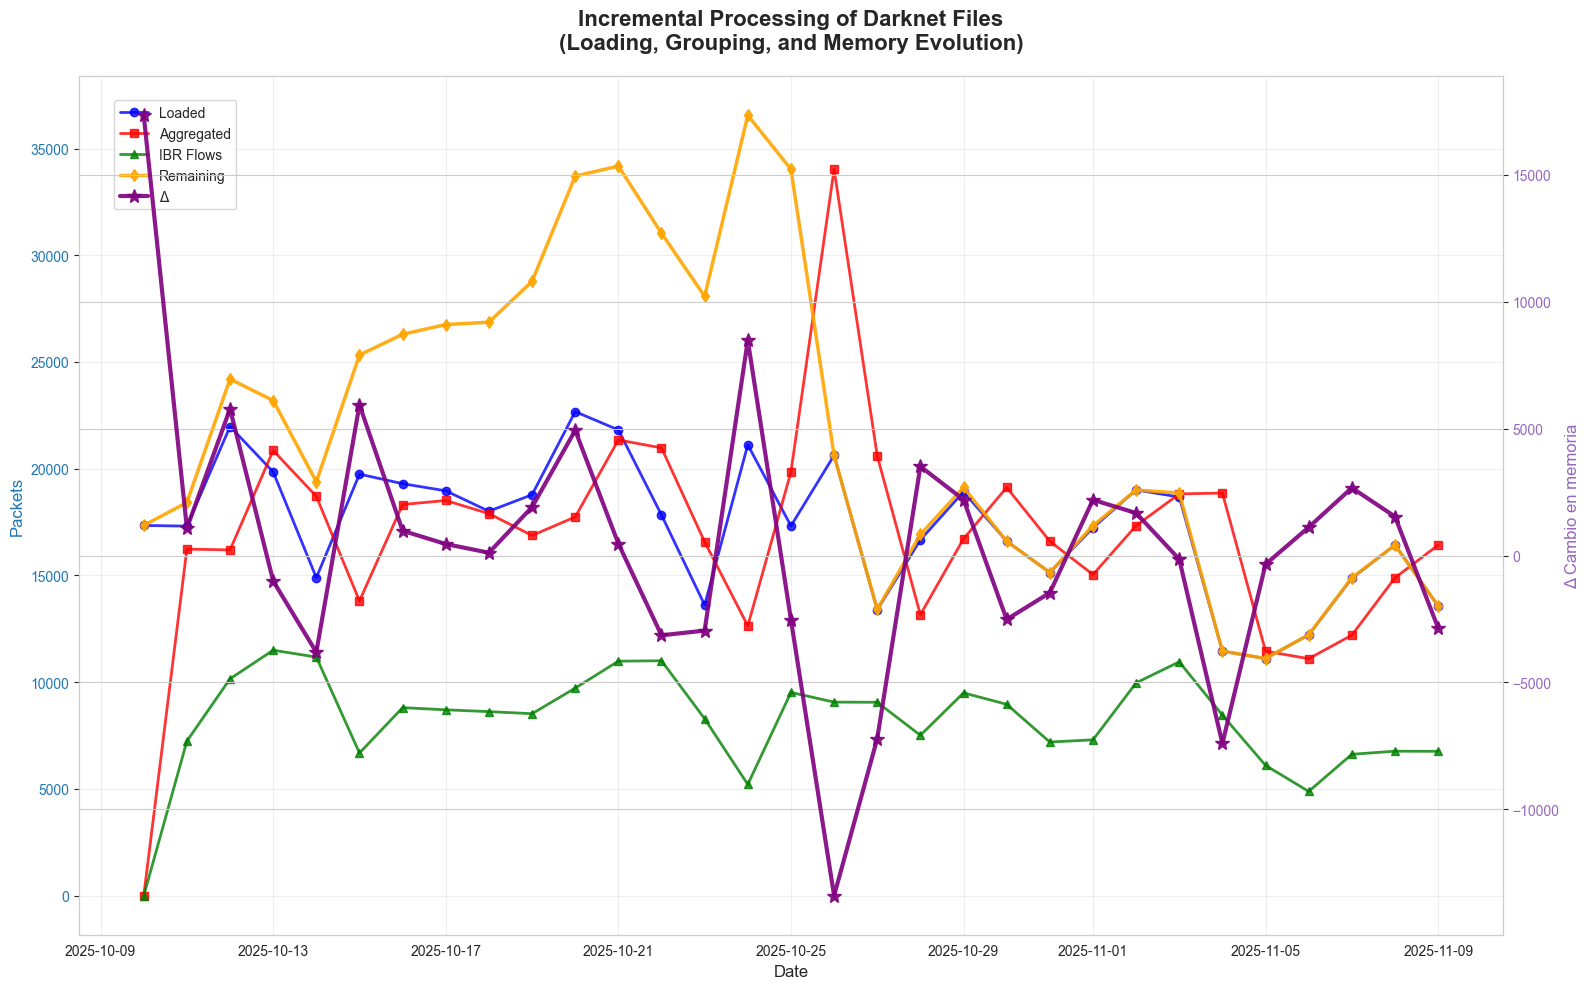

In [4]:
# Seaborn style
sns.set_style("whitegrid")
plt.figure(figsize=(16, 10))

# Create subplots with dual axes
fig, ax1 = plt.subplots(figsize=(16, 10))

# Left axis for Loaded, Aggregated, Groups, Remaining
color1 = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Packets', color=color1, fontsize=12)
l1 = ax1.plot(df['Date'], df['Loaded'], marker='o', linewidth=2, label='Loaded', color='blue', alpha=0.8)
l2 = ax1.plot(df['Date'], df['Aggregated'], marker='s', linewidth=2, label='Aggregated', color='red', alpha=0.8)
l3 = ax1.plot(df['Date'], df['IBR Flows'], marker='^', linewidth=2, label='IBR Flows', color='green', alpha=0.8)
l4 = ax1.plot(df['Date'], df['Remaining'], marker='d', linewidth=2.5, label='Remaining', color='orange', alpha=0.9)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Eje derecho para Delta
ax2 = ax1.twinx()
color2 = 'tab:purple'
ax2.set_ylabel('Δ Cambio en memoria', color=color2, fontsize=12)
l5 = ax2.plot(df['Date'], df['Delta'], marker='*', linewidth=3, label='Δ', color='purple', markersize=10, alpha=0.9)
ax2.tick_params(axis='y', labelcolor=color2)

# Titles and legend
plt.title('Incremental Processing of Darknet Files\n(Loading, Grouping, and Memory Evolution)', 
          fontsize=16, fontweight='bold', pad=20)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(0.02, 0.98))

# Rotate dates on X axis
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [5]:
def plot_processing_with_delta(df, font_size=12):
    """
    Generate plot with dual axis (Delta on right axis)

    Parameters:
    df: DataFrame with columns 'Date', 'Loaded', 'Aggregated', 'Groups', 'Remaining', 'Delta'
    font_size: Font size for all elements (default: 12)
    """
    # Seaborn style
    sns.set_style("whitegrid")
    fig, ax1 = plt.subplots(figsize=(16, 10))

    # Left axis for Loaded, Aggregated, Groups, Remaining
    color1 = 'tab:blue'
    ax1.set_xlabel('Date', fontsize=font_size+2)
    ax1.set_ylabel('Packets', color=color1, fontsize=font_size+2)
    l1 = ax1.plot(df['Date'], df['Loaded'], marker='o', linewidth=3, label='Loaded',
                  color='blue', alpha=0.8, markersize=font_size//2)
    l2 = ax1.plot(df['Date'], df['Aggregated'], marker='s', linewidth=3, label='Aggregated',
                  color='red', alpha=0.8, markersize=font_size//2)
    l3 = ax1.plot(df['Date'], df['IBR Flows'], marker='^', linewidth=3, label='IBR Flows',
                  color='green', alpha=0.8, markersize=font_size//2)
    l4 = ax1.plot(df['Date'], df['Remaining'], marker='d', linewidth=3.5, label='Remaining',
                  color='orange', alpha=0.9, markersize=font_size//2 + 1)
    ax1.tick_params(axis='y', labelcolor=color1, labelsize=font_size)
    ax1.grid(True, alpha=0.3)

    # Right axis for Delta
    ax2 = ax1.twinx()
    color2 = 'tab:purple'
    ax2.set_ylabel('Δ Memory Change', color=color2, fontsize=font_size+2)
    l5 = ax2.plot(df['Date'], df['Delta'], marker='*', linewidth=4, label='Δ',
                  color='purple', markersize=font_size//1.5, alpha=0.9)
    ax2.tick_params(axis='y', labelcolor=color2, labelsize=font_size)

    # Title and legend
    plt.title('Incremental Processing of Darknet Files\n(Loading, Grouping, and Memory Evolution)',
              fontsize=font_size+6, fontweight='bold', pad=20)

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
               bbox_to_anchor=(0.02, 0.98), fontsize=font_size+1)

    # Rotate dates on X axis
    plt.xticks(rotation=45, fontsize=font_size)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_processing_without_delta(df, font_size=12):
    """
    Generate plot WITHOUT dual axis (main metrics only)

    Parameters:
    df: DataFrame with columns 'Date', 'Loaded', 'Aggregated', 'Groups', 'Remaining'
    font_size: Font size for all elements (default: 12)
    """
    # Seaborn style
    sns.set_style("whitegrid")
    plt.figure(figsize=(16, 10))

    # Single axis for all metrics
    plt.xlabel('Date', fontsize=font_size+2)
    plt.ylabel('Packets', fontsize=font_size+2)

    plt.plot(df['Date'], df['Loaded'], marker='o', linewidth=3, label='Loaded',
             color='blue', alpha=0.8, markersize=font_size//2)
    plt.plot(df['Date'], df['Aggregated'], marker='s', linewidth=3, label='Aggregated',
             color='red', alpha=0.8, markersize=font_size//2)
    plt.plot(df['Date'], df['IBR Flows'], marker='^', linewidth=3, label='IBR Flows',
             color='green', alpha=0.8, markersize=font_size//2)
    plt.plot(df['Date'], df['Remaining'], marker='d', linewidth=3.5, label='Remaining',
             color='orange', alpha=0.9, markersize=font_size//2 + 1)

    # plt.title('Incremental Processing of Darknet Files\n(Loading, Grouping, and Memory Evolution)',
    #          fontsize=font_size+6, fontweight='bold', pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=font_size+1)
    plt.xticks(rotation=45, fontsize=font_size)
    plt.yticks(fontsize=font_size)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('icmp_03_agg_echo_request_noipid.pdf', dpi=300)  # Previously ibrflow_agg_icmpscan_noipid.pdf
    plt.show()

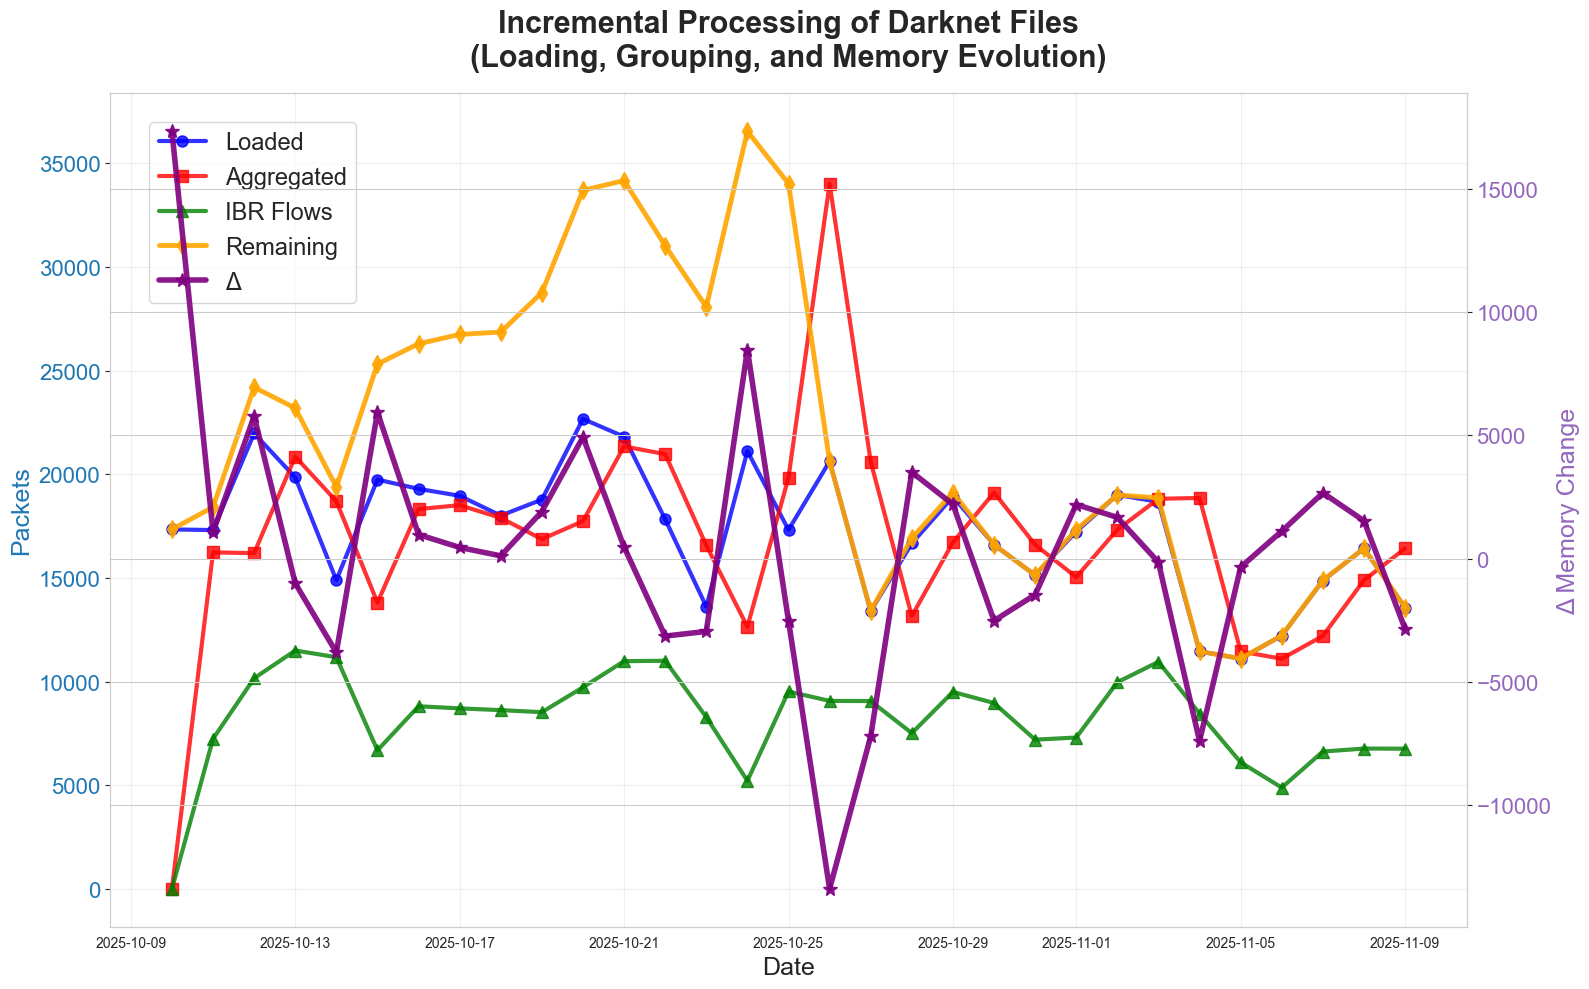

In [7]:
plot_processing_with_delta(df, font_size=16)

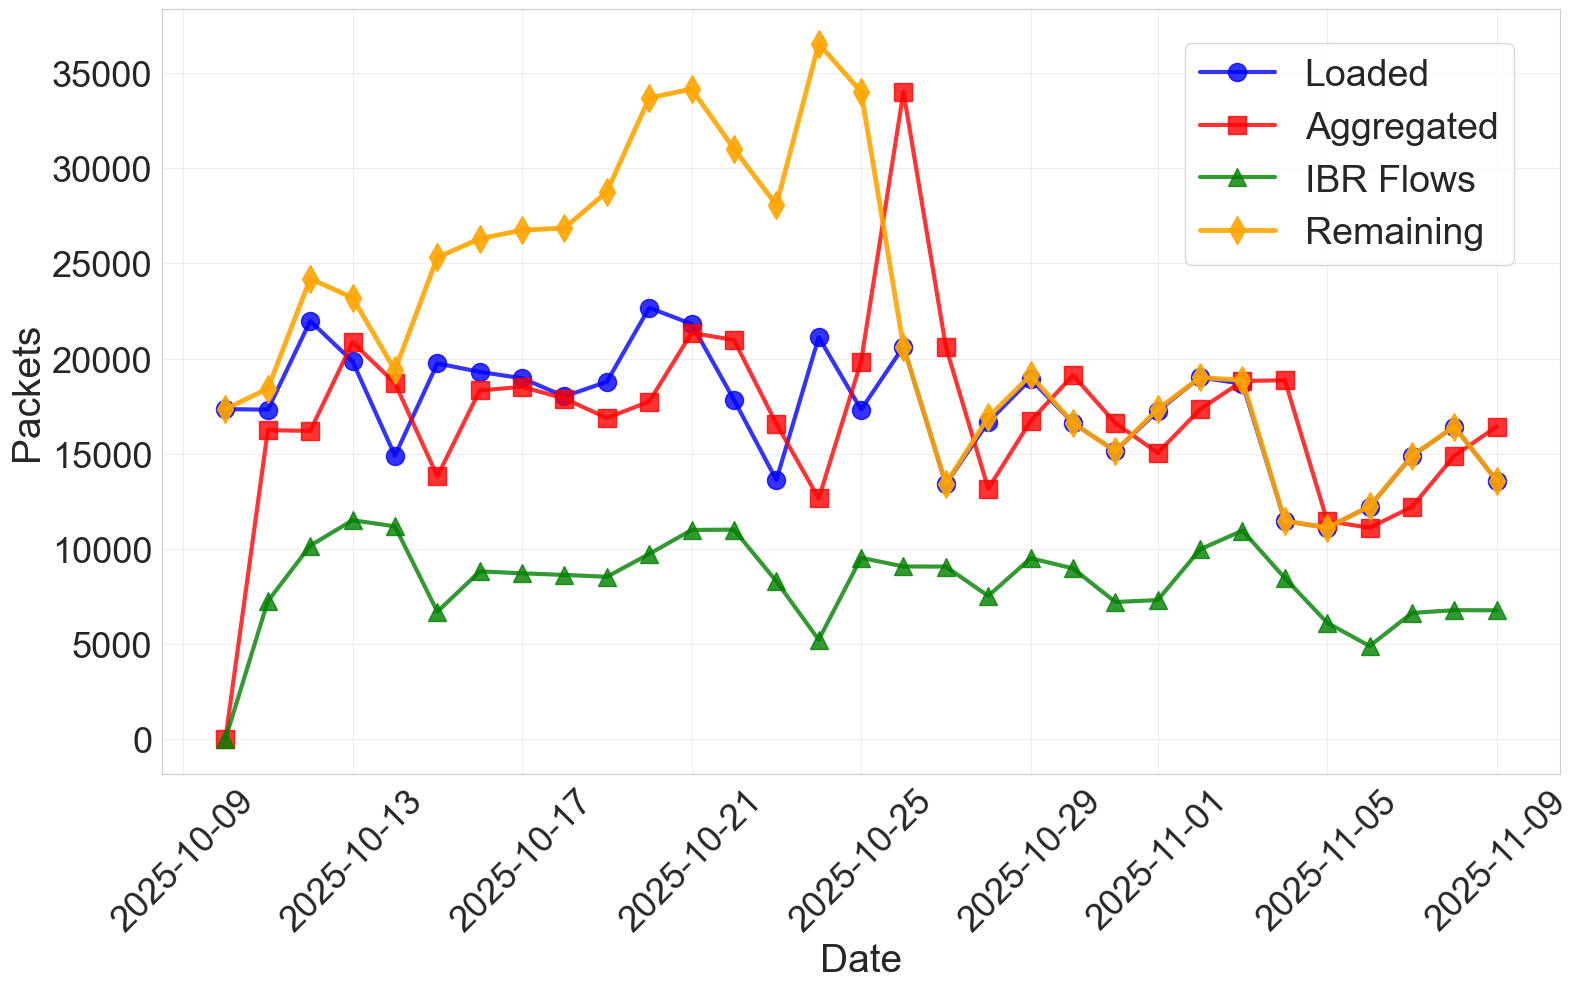

In [8]:
plot_processing_without_delta(df, font_size=26)